<a href="https://colab.research.google.com/github/indujagannathan/Internship-/blob/main/INDUJAGAN1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [10]:
df = pd.read_excel('/content/drive/MyDrive/customer_segmentation_data.xlsx')

In [11]:
df.head()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08


            id        age    gender         income  spending_score  \
cluster                                                              
0         7.00  45.333333  1.333333   63212.666667       65.666667   
1         6.50  25.000000  2.000000   55812.000000       46.000000   
2         2.75  46.000000  0.000000  111347.000000       50.250000   
3        10.00  55.000000  0.000000   45839.000000       55.000000   

         membership_years  purchase_frequency  preferred_category  \
cluster                                                             
0                     8.0               13.00                3.00   
1                     4.0               36.50                1.50   
2                     2.5               29.75                1.75   
3                     7.0                2.00                1.00   

         last_purchase_amount  
cluster                        
0                  892.733333  
1                  139.285000  
2                  231.725000  
3   

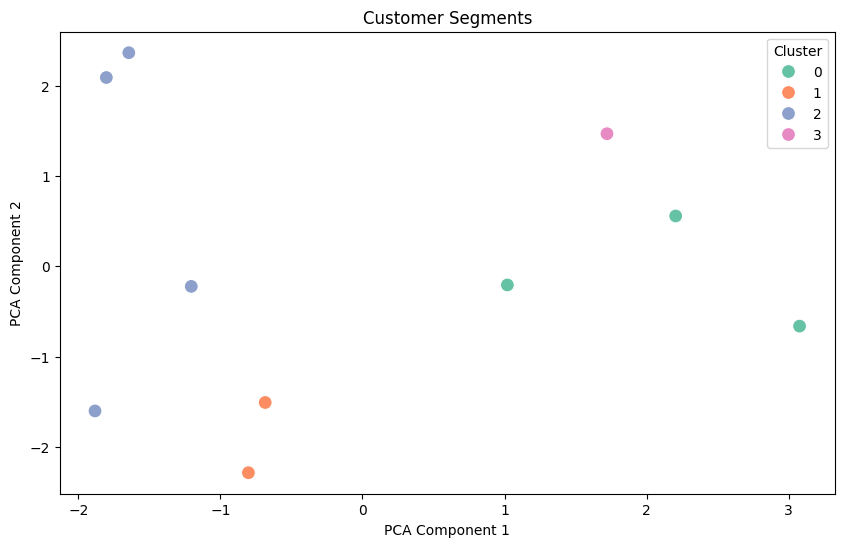

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


data = {
    'id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],  # truncated for brevity
    'age': [38, 21, 60, 40, 65, 31, 19, 43, 53, 55],
    'gender': ['Female', 'Female', 'Female', 'Other', 'Female', 'Other', 'Other', 'Male', 'Male', 'Female'],
    'income': [99342, 78852, 126573, 47099, 140621, 57305, 54319, 108115, 34424, 45839],
    'spending_score': [90, 60, 30, 74, 21, 24, 68, 94, 29, 55],
    'membership_years': [3, 2, 2, 9, 3, 3, 5, 9, 6, 7],
    'purchase_frequency': [24, 42, 28, 5, 25, 30, 43, 27, 7, 2],
    'preferred_category': ['Groceries', 'Sports', 'Clothing', 'Home & Garden', 'Electronics', 'Home & Garden', 'Clothing', 'Groceries', 'Sports', 'Electronics'],
    'last_purchase_amount': [113.53, 41.93, 424.36, 991.93, 347.08, 86.85, 191.72, 734.56, 951.71, 821.18]
}

df = pd.DataFrame(data)


df['gender'] = df['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})
df['preferred_category'] = df['preferred_category'].astype('category').cat.codes

features = df[['age', 'gender', 'income', 'spending_score', 'membership_years', 'purchase_frequency', 'preferred_category', 'last_purchase_amount']]


scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)


cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)


silhouette_avg = silhouette_score(scaled_features, df['cluster'])
print(f'Silhouette Score: {silhouette_avg:.2f}')

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df['cluster'], palette='Set2', s=100)
plt.title('Customer Segments')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()